# 🎲 Monte Carlo: Estimating π
Throwing darts at a unit square and counting how many land inside the inscribed circle.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

plt.style.use("dark_background")
plt.rcParams["figure.dpi"] = 120

rng = np.random.default_rng(42)

# Throw darts
n_darts = 50_000
x = rng.uniform(-1, 1, n_darts)
y = rng.uniform(-1, 1, n_darts)
inside = x**2 + y**2 <= 1

pi_estimate = 4 * inside.sum() / n_darts
print(f"Darts thrown: {n_darts:,}")
print(f"Inside circle: {inside.sum():,}")
print(f"π estimate: {pi_estimate:.6f}")
print(f"True π:     {np.pi:.6f}")
print(f"Error:      {abs(pi_estimate - np.pi):.6f}")

Darts thrown: 50,000
Inside circle: 39,329
π estimate: 3.146320
True π:     3.141593
Error:      0.004727


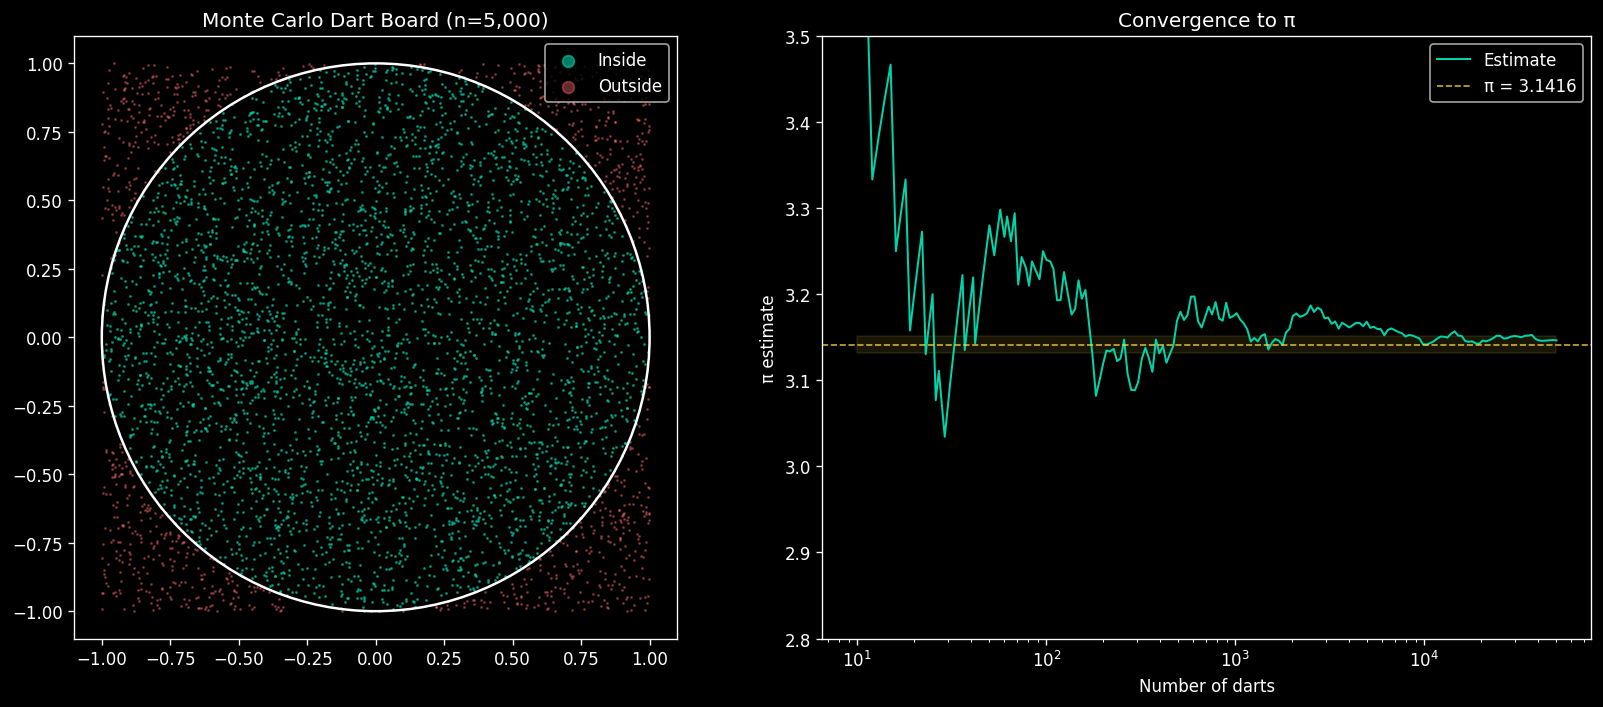

In [2]:
# Visualize the dart board
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: dart scatter (subsample for readability)
subset = 5000
ax = axes[0]
ax.scatter(
    x[:subset][inside[:subset]],
    y[:subset][inside[:subset]],
    s=0.5,
    c="#00d4aa",
    alpha=0.6,
    label="Inside",
)
ax.scatter(
    x[:subset][~inside[:subset]],
    y[:subset][~inside[:subset]],
    s=0.5,
    c="#ff6b6b",
    alpha=0.4,
    label="Outside",
)
circle = Circle((0, 0), 1, fill=False, edgecolor="white", linewidth=1.5)
ax.add_patch(circle)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect("equal")
ax.set_title(f"Monte Carlo Dart Board (n={subset:,})")
ax.legend(markerscale=10, loc="upper right")

# Right: convergence plot
sample_sizes = np.logspace(1, np.log10(n_darts), 200).astype(int)
estimates = np.array([4 * inside[:n].sum() / n for n in sample_sizes])

ax2 = axes[1]
ax2.semilogx(sample_sizes, estimates, color="#00d4aa", linewidth=1.2, label="Estimate")
ax2.axhline(
    np.pi, color="#ffd93d", linestyle="--", linewidth=1, alpha=0.8, label=f"π = {np.pi:.4f}"
)
ax2.fill_between(sample_sizes, np.pi - 0.01, np.pi + 0.01, color="#ffd93d", alpha=0.1)
ax2.set_xlabel("Number of darts")
ax2.set_ylabel("π estimate")
ax2.set_title("Convergence to π")
ax2.legend()
ax2.set_ylim(2.8, 3.5)

plt.tight_layout()
plt.show()

In [3]:
# Statistical analysis across many runs
n_runs = 500
run_sizes = [100, 1_000, 10_000, 100_000]

results = []
for size in run_sizes:
    for run in range(n_runs):
        pts = rng.uniform(-1, 1, (size, 2))
        inside_count = (pts[:, 0] ** 2 + pts[:, 1] ** 2 <= 1).sum()
        est = 4 * inside_count / size
        results.append({"n": size, "run": run, "estimate": est, "error": abs(est - np.pi)})

df = pd.DataFrame(results)
summary = (
    df.groupby("n")
    .agg(
        mean_estimate=("estimate", "mean"),
        std_estimate=("estimate", "std"),
        mean_error=("error", "mean"),
        max_error=("error", "max"),
    )
    .round(6)
)

print("Monte Carlo π — Statistical Summary")
print("=" * 60)
print(summary.to_string())
print()
print("Standard error scales as 1/√n:")
for size in run_sizes:
    theoretical_se = np.sqrt(np.pi * (4 - np.pi) / size)
    observed_se = df[df.n == size]["estimate"].std()
    print(f"  n={size:>7,}: theoretical σ={theoretical_se:.4f}, observed σ={observed_se:.4f}")

Monte Carlo π — Statistical Summary
        mean_estimate  std_estimate  mean_error  max_error
n
100          3.136560      0.161549    0.129581   0.581593
1000         3.145688      0.052387    0.041650   0.161593
10000        3.141390      0.016985    0.013282   0.053607
100000       3.141522      0.005417    0.004382   0.015553

Standard error scales as 1/√n:
  n=    100: theoretical σ=0.1642, observed σ=0.1615
  n=  1,000: theoretical σ=0.0519, observed σ=0.0524
  n= 10,000: theoretical σ=0.0164, observed σ=0.0170
  n=100,000: theoretical σ=0.0052, observed σ=0.0054


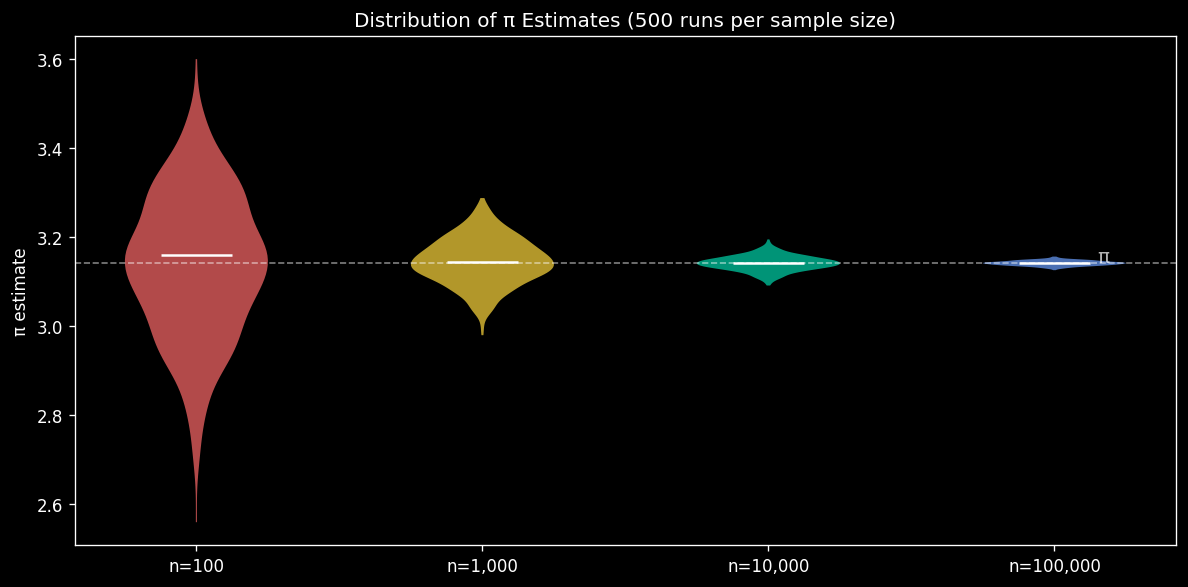

In [4]:
# Error distribution violin plot
fig, ax = plt.subplots(figsize=(10, 5))

positions = range(len(run_sizes))
for i, size in enumerate(run_sizes):
    data = df[df.n == size]["estimate"].values
    parts = ax.violinplot(data, positions=[i], showmedians=True, showextrema=False)
    for pc in parts["bodies"]:
        pc.set_facecolor(["#ff6b6b", "#ffd93d", "#00d4aa", "#6b9fff"][i])
        pc.set_alpha(0.7)
    parts["cmedians"].set_color("white")

ax.axhline(np.pi, color="white", linestyle="--", linewidth=1, alpha=0.5)
ax.text(3.15, np.pi + 0.002, "π", color="white", fontsize=12, alpha=0.7)
ax.set_xticks(positions)
ax.set_xticklabels([f"n={s:,}" for s in run_sizes])
ax.set_ylabel("π estimate")
ax.set_title(f"Distribution of π Estimates ({n_runs} runs per sample size)")

plt.tight_layout()
plt.show()